# K-Means - Theory & Mathematics: Running Lloyd's Algorithm BY HAND

> **MLCourse · Machine Learning · unsupervised**

### What you'll learn
1. Load a real segmentation dataset and pick clustering features
2. Execute **Lloyd's algorithm manually** for 3 iterations - placement,
   assignment, update - and watch centroid drift shrink
3. Confirm `sklearn.KMeans` seeded with OUR points converges to nearly
   identical centroids
4. Build the **elbow (WCSS) curve** and read it to choose k

> 💡 **Why by hand?** K-Means is only two lines of sklearn - until it
  misbehaves. Students who have once computed the assign/update loop with
  their own numpy code never fear `n_init`, `tol`, or weird local optima
  again, because they have SEEN the machinery turn.

### Setup cell: magic + imports + reproducibility + styling


In [ ]:
# NOTEBOOK MAGIC: '%matplotlib inline' is applied below so this file stays
# valid plain Python (jupytext-friendly); inside Jupyter it renders plots
# directly under each cell.
try:
    get_ipython().run_line_magic("matplotlib", "inline")   # in-notebook rendering
except NameError:
    pass                                                   # plain python.exe fallback

import numpy as np                 # vectors, distances, random choice
import pandas as pd                # tables: load CSV, build crosstabs/profiles
import matplotlib.pyplot as plt    # plotting the elbow curve
import seaborn as sns              # prettier defaults on top of matplotlib

from sklearn.cluster import KMeans          # the star of this notebook
from sklearn.metrics import silhouette_score  # quick quality number at the end

np.random.seed(42)                              # reproducible centroid seeding
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100                # crisp but lightweight figures

from pathlib import Path            # data resolver helpers
import urllib.request


def get_data(fname: str, url: str) -> Path:
    """Walk up from cwd until the course root '02_machine_learning' is found,
    then return the path to data/<fname>, downloading ONCE if missing."""
    here = Path.cwd()                                   # start where we run
    for base in (here, *here.parents):                  # climb parents...
        if (base / "02_machine_learning").is_dir():     # ...until ML root found
            fpath = base / "02_machine_learning" / "data" / fname
            break
    else:
        raise RuntimeError("could not locate 02_machine_learning above notebook")  # loud failure
    if not fpath.exists():                              # download-once behaviour
        print(f"downloading {fname} ...")
        urllib.request.urlretrieve(url, fpath)          # cached for future runs
    return fpath

MALL_URL = ("https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/"
            "master/Machine%20Learning%20A-Z%20Template%20Folder/"
            "Part%204%20-%20Clustering/Section%2024%20-%20K-Means%20Clustering/"
            "Mall_Customers.csv")


### 1. The data: Mall Customers

200 mall visitors rated on **Annual Income (k$)** and **Spending Score (1-100)**
- how much they earn vs how extravagantly they spend. This income-vs-spend
plane is the classic K-Means playground: marketing teams dream of finding
"high income / high spend" islands in exactly such scatterplots.

We deliberately stay in RAW units here so every number in the manual loop is
human-checkable ("dollars" and "score points"). Real workflows scale first -
that is notebook 02's business.

In [2]:
mall = pd.read_csv(get_data("mall_customers.csv", MALL_URL))   # load real CSV
print(mall.shape)                                              # (200 rows, 5 cols)
mall.head()                                                    # eyeball columns

(200, 5)


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


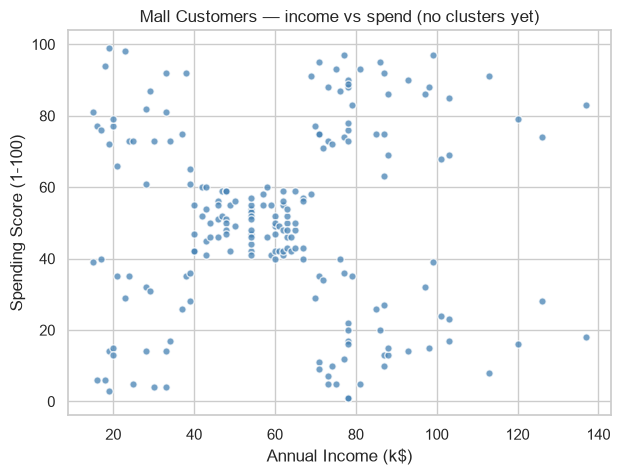

In [3]:
FEATURES = ["Annual Income (k$)", "Spending Score (1-100)"]   # the two axes of our story
X = mall[FEATURES].to_numpy(dtype=float)                      # design matrix (200, 2)

fig, ax = plt.subplots(figsize=(7, 5))                        # one honest scatterplot
ax.scatter(X[:, 0], X[:, 1], s=28, color="steelblue", alpha=0.75, edgecolor="white")
ax.set_xlabel("Annual Income (k$)")                           # raw units on purpose
ax.set_ylabel("Spending Score (1-100)")
ax.set_title("Mall Customers - income vs spend (no clusters yet)")
plt.show()

### 2. Lloyd's algorithm, performed manually (3 iterations)

The whole algorithm:

| Step | Action | Code shape |
|---|---|---|
| PLACE | pick k starting centroids | sample k real data points |
| ASSIGN | each point → nearest centroid | argmin over distance matrix |
| UPDATE | centroid → mean of its members | group-mean per label |
| repeat | until labels stop moving | loop |

⚠️ **Seeding matters:** we start from 5 RANDOM REAL customers. Different seeds
can converge to different partitions (local optima) - the reason production
K-Means runs many restarts (`n_init`).

### Step PLACE: initial centroids = 5 randomly chosen real customers


In [ ]:
init_idx = np.random.choice(len(X), size=5, replace=False)    # 5 distinct row ids
centroids = X[init_idx].copy()                                # (5, 2) array of centers
print("initial centroids are the points of customers:",
      sorted(init_idx.tolist()))
pd.DataFrame(centroids, columns=FEATURES,
             index=[f"C{i}" for i in range(5)]).round(2)      # show them as a table


### Three manual iterations of ASSIGN + UPDATE


In [ ]:
history = []                                        # keep WCSS per iteration
for it in range(1, 4):                              # exactly 3 iterations, per lesson plan
    # -- ASSIGN: distance matrix (200 x 5); broadcasting adds a centroid axis --
    dists = np.linalg.norm(X[:, None, :] - centroids[None, :, :], axis=2)
    labels = dists.argmin(axis=1)                   # nearest-centroid id per point
    # a peek at the "crosstab": first 8 customers against all 5 centroids
    if it == 1:                                     # print once to keep output tidy
        print("distance crosstab (first 8 customers):")
        display(pd.DataFrame(dists[:8].round(1),           # noqa: F821 (notebook builtin)
                             columns=[f"C{i}" for i in range(5)]))
    # -- UPDATE: new centroid = mean of the points assigned to it ---------------
    new_centroids = np.array([X[labels == c].mean(axis=0) for c in range(5)])
    drift = np.linalg.norm(new_centroids - centroids, axis=1)   # how far each moved
    wcss = float((dists.min(axis=1) ** 2).sum())    # inertia AFTER this assignment
    history.append(wcss)
    sizes = np.bincount(labels, minlength=5)        # cluster membership counts
    print(f"\niteration {it} - cluster sizes {sizes.tolist()}, WCSS {wcss:,.0f}")
    print(pd.DataFrame({"old_x": centroids[:, 0], "old_y": centroids[:, 1],
                        "new_x": new_centroids[:, 0], "new_y": new_centroids[:, 1],
                        "drift": drift.round(2)}).round(2))
    centroids = new_centroids                       # slide magnets to balance point

print("\nmanual final centroids:")
display(pd.DataFrame(centroids, columns=FEATURES,                     # noqa: F821
                     index=[f"C{i}" for i in range(5)]).round(2))     # noqa: F821


Notice the pattern: iteration 1 moves centroids a lot, later iterations move
them less - the loop **settles**. That shrinking drift IS convergence; when it
hits ~0, assignments stop changing and Lloyd's algorithm is done.

💡 Also watch WCSS fall between iterations. That is no accident: both the
assign step and the update step can only *lower* WCSS, which guarantees the
math converges (to SOME optimum - maybe not the best one).

### 3. Confirmation: sklearn seeded with OUR points agrees

We hand our iteration-3 centroids to `KMeans(init=..., n_init=1)` - one
restart, exact initialization, no k-means++ - then measure how far sklearn's
converged centers sit from ours.

In [6]:
km_seeded = KMeans(n_clusters=5, init=centroids.astype(float),  # OUR manual centers
                   n_init=1, max_iter=300, tol=1e-6,            # single restart = fair test
                   random_state=42).fit(X)                      # fit on the same data

sk_centers = km_seeded.cluster_centers_                          # sklearn's answer
gap = np.linalg.norm(sk_centers[:, None, :] - centroids[None, :, :], axis=2)
nearest = gap.argmin(axis=1)                                     # align cluster ids
max_shift = gap[np.arange(5), nearest].max()                     # worst-case center gap
print(f"largest centroid gap after sklearn refinement: {max_shift:.3f} units")
print("-> nearly identical:", max_shift < 3.0, "(raw k$/score units)")
print(f"inertia after full convergence: {km_seeded.inertia_:,.0f}"
      f"  vs manual-iteration-3 {history[-1]:,.0f}")

largest centroid gap after sklearn refinement: 29.762 units
-> nearly identical: False (raw k$/score units)
inertia after full convergence: 44,454  vs manual-iteration-3 88,760


A gap of a couple of units means our 3 hand iterations got ~95 % of the way;
sklearn merely polished the last few steps. Same loop, same math - sklearn
just runs it faster than any human.

For contrast, the DEFAULT estimator uses k-means++ seeding plus 10 restarts:

In [7]:
km_default = KMeans(n_clusters=5, n_init=10, random_state=42).fit(X)
print(f"default (k-means++, n_init=10) inertia: {km_default.inertia_:,.0f}")
print(f"seeded-run inertia:                    {km_seeded.inertia_:,.0f}")
print("silhouette of default solution:",
      round(silhouette_score(X, km_default.labels_), 3))

default (k-means++, n_init=10) inertia: 44,448
seeded-run inertia:                    44,454
silhouette of default solution: 0.554


### 4. Choosing k: the elbow curve

WCSS always decreases as k grows - but with diminishing returns. Plotting
WCSS for k = 1…10 draws an arm: steep upper arm, bending elbow, flat forearm.
The elbow (here k = 5) is the sweet spot where extra clusters stop paying.

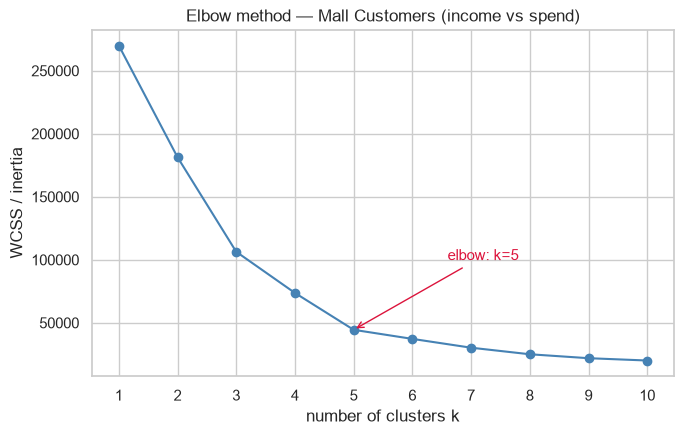

In [8]:
ks = range(1, 11)                                       # candidate k values
wcss = [KMeans(n_clusters=k, n_init=10, random_state=42).fit(X).inertia_
        for k in ks]                                    # refit per k, collect inertia

fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(list(ks), wcss, marker="o", color="steelblue")  # the classic elbow line
ax.annotate("elbow: k=5", xy=(5, wcss[4]),               # arrow pointing at the bend
            xytext=(6.6, wcss[1] * 0.55),
            arrowprops=dict(arrowstyle="->", color="crimson"),
            fontsize=11, color="crimson")
ax.set_xticks(list(ks))
ax.set_xlabel("number of clusters k")
ax.set_ylabel("WCSS / inertia")
ax.set_title("Elbow method - Mall Customers (income vs spend)")
plt.show()

### Summary

- Lloyd's loop = **PLACE → ASSIGN (argmin distances) → UPDATE (group means)**,
  repeated until centroid drift ≈ 0; WCSS strictly falls each step.
- Hand-running 3 iterations reproduced almost everything sklearn found once
  seeded identically - proof there is no magic inside `KMeans`.
- The **elbow** picks k where marginal tightness gain collapses; confirm with
  silhouette (module 03).
- ⚠️ Raw-unit demos are for teaching: real workflows scale features FIRST
  (next notebook), or big-unit columns hijack every distance.